# DA6401 Assignment 1 — MLP for Image Classification
**Author:** Mohd Shadab | **Roll:** MA24M015

## What this notebook does (in order):
1. Setup: clone repo, install packages, login to W&B
2. **Q2.1** — Data exploration table (5 images × 10 classes)
3. **Q2.2** — Hyperparameter sweep (100 runs, Bayesian)
4. **Q2.3** — Optimizer showdown (all 6 optimizers)
5. **Q2.4** — Vanishing gradient: Sigmoid vs ReLU
6. **Q2.5** — Dead neuron investigation (high LR + ReLU vs Tanh)
7. **Q2.6** — Cross-entropy vs MSE comparison
8. **Q2.7** — Global train vs val accuracy scatter
9. **Q2.8** — Confusion matrix + creative error visualization
10. **Q2.9** — Zeros vs Xavier symmetry breaking
11. **Q2.10** — Fashion-MNIST transfer challenge

---
# STEP 1: Setup

In [1]:
import os
os.environ["WANDB_ENTITY"] = "iitm_assigment"

GITHUB_USERNAME = 'shadab007-byte'
WANDB_PROJECT   = 'da6401-assignment-1'
WANDB_ENTITY    = 'iitm_assigment'

# Clone repository
import os
if not os.path.exists('da6401_assignment_1'):
    !git clone https://github.com/{GITHUB_USERNAME}/da6401_assignment_1.git
%cd da6401_assignment_1
!ls src/ann/

Cloning into 'da6401_assignment_1'...
remote: Enumerating objects: 372, done.
remote: Counting objects: 100% (372/372), done.
remote: Compressing objects: 100% (264/264), done.
remote: Total 372 (delta 126), reused 237 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (372/372), 3.88 MiB | 12.34 MiB/s, done.
Resolving deltas: 100% (126/126), done.
/content/da6401_assignment_1
activations.py	neural_layer.py    objective_functions.py
__init__.py	neural_network.py  optimizers.py


In [ ]:
!pip install wandb scikit-learn keras tensorflow -q
print('Packages installed!')

Packages installed!


In [2]:
import wandb

wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ma24m015 (iitm_assigment) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json, os
from sklearn.metrics import confusion_matrix

from ann.neural_network import NeuralNetwork
from ann.optimizers import get_optimizer
from utils.data_loader import load_dataset, to_onehot, get_batches, get_class_names
from utils.metrics import compute_metrics, get_confusion_matrix

print(' All imports successful!')

 All imports successful!


In [4]:
#load both datasets
print('Loading MNIST...')
X_tr, y_tr, X_val, y_val, X_te, y_te = load_dataset('mnist')
y_tr_oh  = to_onehot(y_tr)
y_val_oh = to_onehot(y_val)
y_te_oh  = to_onehot(y_te)

print('Loading Fashion-MNIST...')
X_tr_f, y_tr_f, X_val_f, y_val_f, X_te_f, y_te_f = load_dataset('fashion_mnist')
y_tr_f_oh  = to_onehot(y_tr_f)
y_val_f_oh = to_onehot(y_val_f)

print('\n Both datasets loaded!')

Loading MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[info] mnist → Train:54000, Val:6000, Test:10000
Loading Fashion-MNIST...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[info] fashion_mnist → Train:54000, Val:6000, Test:10000

 Both datasets loaded!


In [5]:
import argparse

def build_and_train(
    X_train, y_train_oh, X_val, y_val_oh, y_val_int,
    hidden_sizes, activation, optimizer_name, learning_rate,
    weight_init='xavier', loss_name='cross_entropy',
    epochs=10, batch_size=64, weight_decay=0.0,
    log_grad_norms=False, log_activations=False,
    use_wandb=True
):
    """Build model, attach optimizer, train, log to W&B. Returns (model, history)."""

    #build CLI-args namespace
    args = argparse.Namespace(
        num_layers=len(hidden_sizes),
        hidden_size=hidden_sizes,
        activation=activation,
        weight_init=weight_init,
        loss=loss_name,
        weight_decay=weight_decay,
    )
    model = NeuralNetwork(cli_args=args)

    #optimizer setup
    opt_kw = dict(learning_rate=learning_rate, weight_decay=weight_decay)
    if optimizer_name in ['momentum', 'nag']:
        opt_kw['beta'] = 0.9
    elif optimizer_name == 'rmsprop':
        opt_kw['beta'] = 0.9; opt_kw['eps'] = 1e-8
    elif optimizer_name in ['adam', 'nadam']:
        opt_kw['beta1'] = 0.9; opt_kw['beta2'] = 0.999; opt_kw['eps'] = 1e-8

    model.optimizer = get_optimizer(optimizer_name, **opt_kw)
    use_nag = model.optimizer.is_nag  # True only for NAG

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        losses = []
        for Xb, yb in get_batches(X_train, y_train_oh, batch_size):

            if use_nag:
                model.optimizer.apply_lookahead(model.layers)
            logits = model.forward(Xb)
            model.backward(yb, logits)
            model.update_weights()
            losses.append(model._last_loss)

        train_loss = float(np.mean(losses))
        train_acc  = float(np.mean(model.predict(X_train) == np.argmax(y_train_oh, 1)))

        val_logits = model.forward(X_val)
        from ann.objective_functions import get_loss as _gl
        val_loss, _ = _gl(loss_name)(val_logits, y_val_oh)
        val_acc     = float(np.mean(model.predict(X_val) == y_val_int))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(float(val_loss))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        log_dict = {
            'epoch': epoch,
            'train_loss': train_loss, 'val_loss': float(val_loss),
            'train_accuracy': train_acc, 'val_accuracy': val_acc
        }
        if log_grad_norms:
            for name, norm in model.get_gradient_norms():
                log_dict[name] = norm
        if log_activations:
            log_dict.update(model.get_activation_stats())
        if use_wandb:
            wandb.log(log_dict)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep {epoch:3d} | loss={train_loss:.4f} | val_acc={val_acc:.4f}')

    return model, history

print(' Helper defined!')

 Helper defined!


---
# Q2.1 — Data Exploration & Class Distribution (3 Marks)
**What to do:** Log a W&B Table with 5 sample images from each of the 10 classes.

/tmp/ipython-input-660/3660775820.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([fashion_cls[i] for i in unique], rotation=45, ha='right')


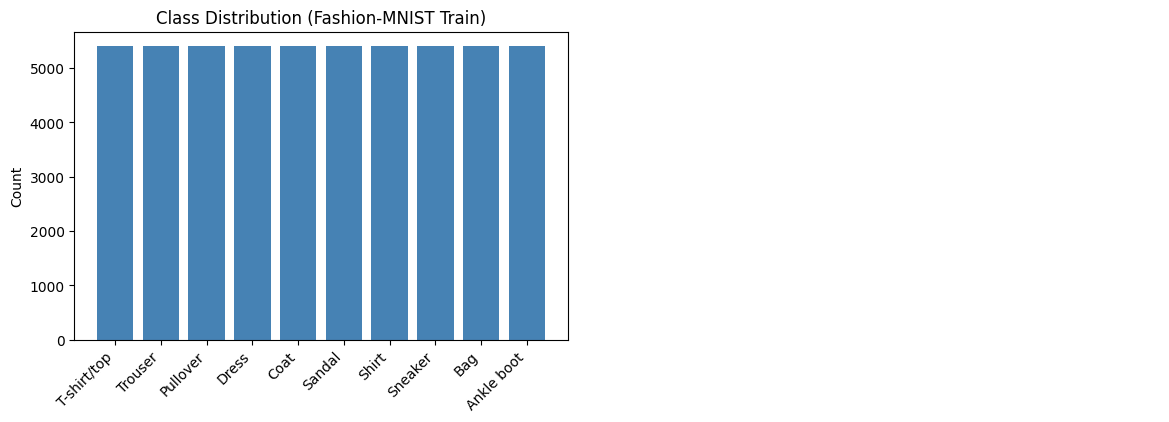

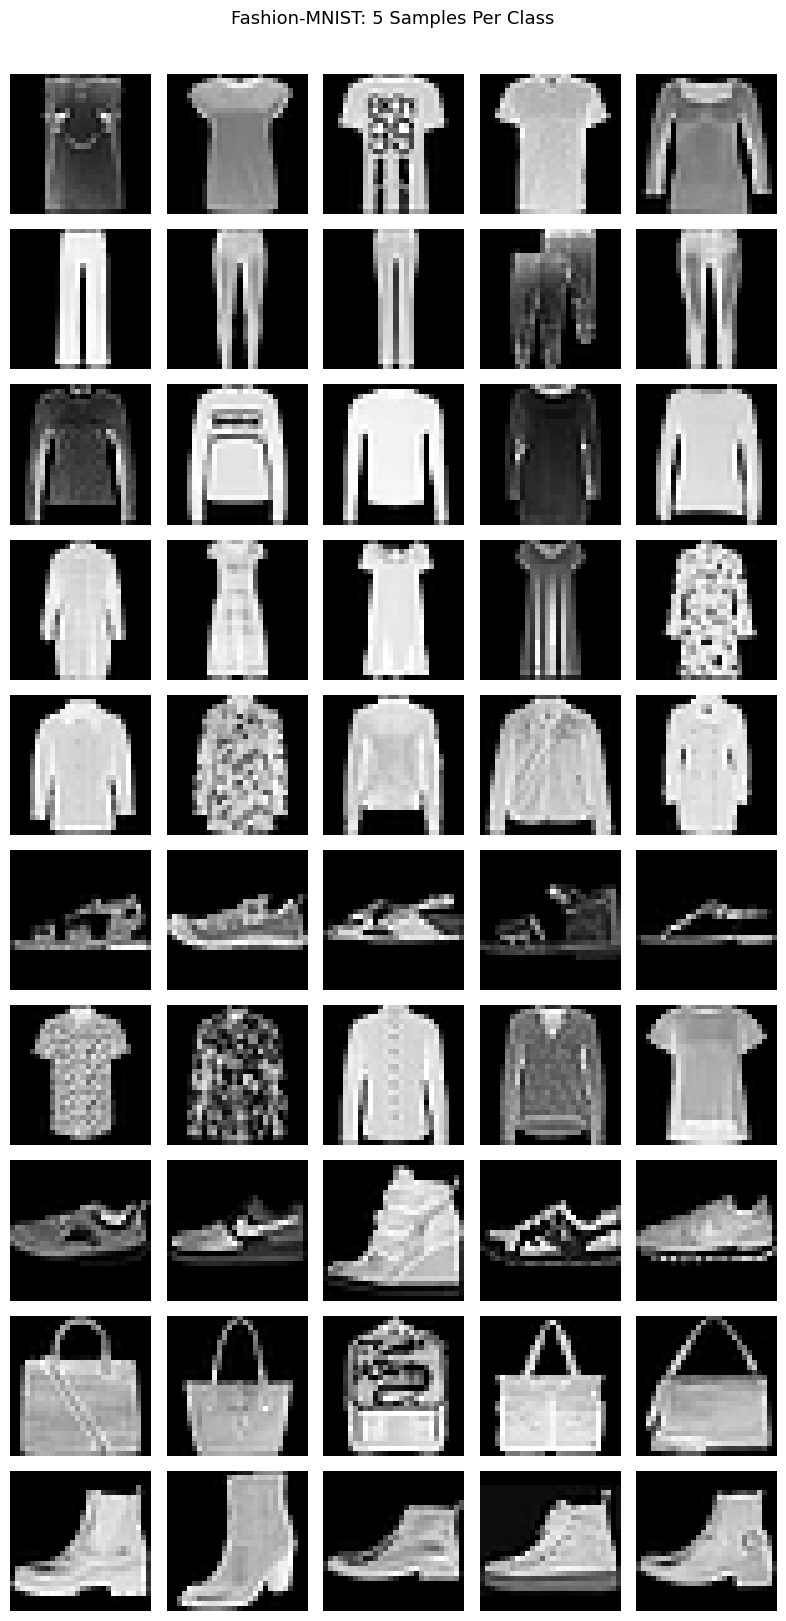

✓ Q2.1 Done! W&B project → Runs → q2-1-data-exploration → Tables tab


In [ ]:
fashion_cls = get_class_names('fashion_mnist')

run = wandb.init(project=WANDB_PROJECT, name='q2-1-data-exploration', job_type='data')

#W&B Table: 5 images per class ──
cols  = ['class_id', 'class_name'] + [f'sample_{i+1}' for i in range(5)]
table = wandb.Table(columns=cols)

for cid in range(10):
    idxs   = np.where(y_tr_f == cid)[0][:5]
    wb_imgs = [wandb.Image((X_tr_f[i].reshape(28,28)*255).astype(np.uint8),
                            caption=fashion_cls[cid]) for i in idxs]
    table.add_data(cid, fashion_cls[cid], *wb_imgs)

wandb.log({'class_sample_table': table})

#class distribution bar chart
unique, counts = np.unique(y_tr_f, return_counts=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar([fashion_cls[i] for i in unique], counts, color='steelblue')
axes[0].set_title('Class Distribution (Fashion-MNIST Train)')
axes[0].set_xticklabels([fashion_cls[i] for i in unique], rotation=45, ha='right')
axes[0].set_ylabel('Count')

#grid: 5 images × 10 classes
axes[1].axis('off')

fig2, ax2 = plt.subplots(10, 5, figsize=(8, 16))
for cid in range(10):
    idxs = np.where(y_tr_f == cid)[0][:5]
    for j, idx in enumerate(idxs):
        ax2[cid, j].imshow(X_tr_f[idx].reshape(28,28), cmap='gray')
        ax2[cid, j].axis('off')
    ax2[cid, 0].set_ylabel(fashion_cls[cid], fontsize=8, rotation=0, ha='right', labelpad=40)
plt.suptitle('Fashion-MNIST: 5 Samples Per Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('class_grid.png', dpi=100, bbox_inches='tight')
wandb.log({'class_grid': wandb.Image('class_grid.png')})
plt.show()

wandb.finish()
print(' Q2.1 Done! W&B project → Runs → q2-1-data-exploration → Tables tab')

---
# Q2.2 — Hyperparameter Sweep (6 Marks) — 100+ runs
**What to do:** Run 100+ configurations. In W&B, look at Parallel Coordinates plot to find which hyperparameter matters most.

In [ ]:
sweep_config = {
    'method': 'bayes',  # Bayesian is smarter than random — finds good configs faster
    'metric': {'name': 'val_accuracy', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {'values': [0.001, 0.0005, 0.0001, 0.005, 0.01]},
        'optimizer':     {'values': ['adam', 'nadam', 'rmsprop', 'momentum', 'sgd', 'nag']},
        'activation':    {'values': ['relu', 'tanh', 'sigmoid']},
        'num_layers':    {'values': [2, 3, 4]},
        'hidden_size':   {'values': [32, 64, 128]},
        'batch_size':    {'values': [32, 64, 128]},
        'weight_init':   {'values': ['xavier', 'random']},
        'weight_decay':  {'values': [0.0, 0.0001, 0.0005]},
    }
}

def sweep_run():
    run = wandb.init()
    cfg = wandb.config
    model, hist = build_and_train(
        X_tr, y_tr_oh, X_val, y_val_oh, y_val,
        hidden_sizes   = [cfg.hidden_size] * cfg.num_layers,
        activation     = cfg.activation,
        optimizer_name = cfg.optimizer,
        learning_rate  = cfg.learning_rate,
        weight_init    = cfg.weight_init,
        loss_name      = 'cross_entropy',
        epochs         = 10,
        batch_size     = cfg.batch_size,
        weight_decay   = cfg.weight_decay,
        use_wandb      = True
    )
    wandb.finish()

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT)
print(f'Sweep ID: {sweep_id}')
print('Starting 100 runs... (this takes ~1-2 hours on Colab GPU)')
print('You can watch progress live at: https://wandb.ai')

wandb.agent(sweep_id, function=sweep_run, count=100)

Create sweep with ID: nzpuk5ui
Sweep URL: https://wandb.ai/iitm_assigment/da6401-assignment-1/sweeps/nzpuk5ui
Sweep ID: nzpuk5ui
Starting 100 runs... (this takes ~1-2 hours on Colab GPU)
You can watch progress live at: https://wandb.ai


wandb: Agent Starting Run: ykap16ty with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 2
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  Ep   1 | loss=0.7150 | val_acc=0.8998
  Ep   5 | loss=0.2111 | val_acc=0.9363
  Ep  10 | loss=0.1408 | val_acc=0.9542


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▄▅▆▆▇▇██
train_loss,█▃▃▂▂▂▁▁▁▁
val_accuracy,▁▃▄▅▆▆▇▇██
val_loss,█▆▅▄▃▂▂▂▁▁
epoch,10
train_accuracy,0.96202
train_loss,0.14077
val_accuracy,0.95417
val_loss,0.16767


wandb: Agent Starting Run: 41dxu5zc with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.0001
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

  Ep   1 | loss=0.5511 | val_acc=0.9310
  Ep   5 | loss=0.0875 | val_acc=0.9678
  Ep  10 | loss=0.0426 | val_acc=0.9717


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▅▆▇▇████
train_loss,█▃▂▂▂▁▁▁▁▁
val_accuracy,▁▅▆▇▇█████
val_loss,█▄▃▂▂▁▁▁▁▁
epoch,10
train_accuracy,0.98928
train_loss,0.0426
val_accuracy,0.97167
val_loss,0.10195


wandb: Agent Starting Run: t7v8j0xt with config:
wandb: 	activation: tanh
wandb: 	batch_size: 128
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 4
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  Ep   1 | loss=0.4330 | val_acc=0.9212
  Ep   5 | loss=0.1117 | val_acc=0.9605
  Ep  10 | loss=0.0633 | val_acc=0.9700


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▄▅▆▇▇███
train_loss,█▄▃▂▂▂▁▁▁▁
val_accuracy,▁▄▅▆▆▇▇███
val_loss,█▅▄▃▂▂▂▁▁▁
epoch,10
train_accuracy,0.9848
train_loss,0.06334
val_accuracy,0.97
val_loss,0.10022


---
# Q2.3 — Optimizer Showdown (5 Marks)
**What to do:** Compare all 6 optimizers on same 3L-128-ReLU architecture.


Training with SGD...


  Ep   1 | loss=1.0231 | val_acc=0.8788
  Ep   5 | loss=0.2240 | val_acc=0.9272
  Ep  10 | loss=0.1434 | val_acc=0.9533


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▅▅▆▇▇▇██
train_loss,█▃▂▂▂▁▁▁▁▁
val_accuracy,▁▄▅▆▆▇▇█▇█
val_loss,█▅▄▃▃▂▂▁▁▁
epoch,10
train_accuracy,0.96085
train_loss,0.14337
val_accuracy,0.95333
val_loss,0.16734



Training with MOMENTUM...


  Ep   1 | loss=0.3963 | val_acc=0.9472
  Ep   5 | loss=0.0625 | val_acc=0.9720
  Ep  10 | loss=0.0227 | val_acc=0.9725


...

  Ep   1 | loss=0.2694 | val_acc=0.9613
  Ep   5 | loss=0.0458 | val_acc=0.9735
  Ep  10 | loss=0.0210 | val_acc=0.9715


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▄▅▇▆▇▇██
train_loss,█▄▃▂▂▁▁▁▁▁
val_accuracy,▁▂▂▄▇▅█▆▇▆
val_loss,█▅▇▅▁▆▂▆▄▇
epoch,10
train_accuracy,0.99457
train_loss,0.02103
val_accuracy,0.9715
val_loss,0.13312



Training with NADAM...


  Ep   1 | loss=0.2595 | val_acc=0.9603
  Ep   5 | loss=0.0447 | val_acc=0.9737
  Ep  10 | loss=0.0226 | val_acc=0.9765


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▂▆▆▇▇████
train_loss,█▃▃▂▂▁▁▁▁▁
val_accuracy,▁▂▅▄▆▇█▇█▇
val_loss,█▇▂▅▁▃▁▃▂▃
epoch,10
train_accuracy,0.99443
train_loss,0.02257
val_accuracy,0.9765
val_loss,0.09968


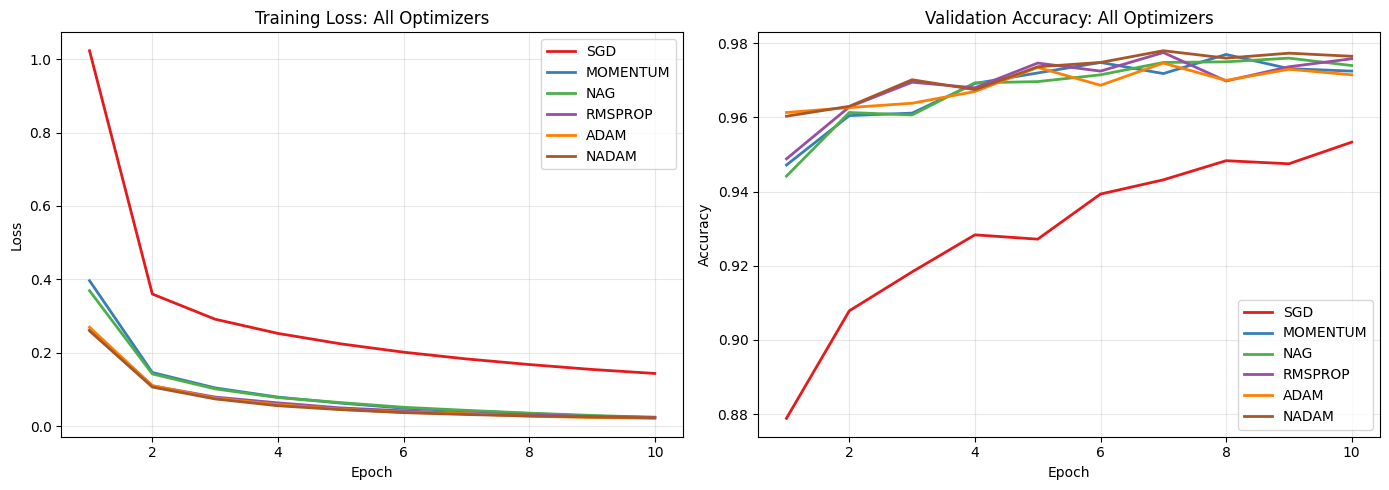


Loss after 5 epochs:
  sgd       : 0.2240
  momentum  : 0.0625
  nag       : 0.0640
  rmsprop   : 0.0495
  adam      : 0.0458
  nadam     : 0.0447


In [ ]:
OPTS = ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']
# Adam/Nadam/RMSProp need lower LR; SGD/Momentum/NAG use higher LR
OPT_LR = {'sgd': 0.01, 'momentum': 0.01, 'nag': 0.01,
           'rmsprop': 0.001, 'adam': 0.001, 'nadam': 0.001}

opt_histories = {}

for opt_name in OPTS:
    print(f'\nTraining with {opt_name.upper()}...')
    run = wandb.init(
        project=WANDB_PROJECT,
        name=f'q2-3-{opt_name}',
        config={'optimizer': opt_name, 'lr': OPT_LR[opt_name]}
    )
    model, hist = build_and_train(
        X_tr, y_tr_oh, X_val, y_val_oh, y_val,
        hidden_sizes=[128, 128, 128], activation='relu',
        optimizer_name=opt_name, learning_rate=OPT_LR[opt_name],
        epochs=10, batch_size=64, use_wandb=True
    )
    opt_histories[opt_name] = hist
    wandb.finish()

#plot comparison
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (opt, hist) in enumerate(opt_histories.items()):
    ep = range(1, len(hist['train_loss'])+1)
    axes[0].plot(ep, hist['train_loss'], label=opt.upper(), color=colors[i], lw=2)
    axes[1].plot(ep, hist['val_acc'],   label=opt.upper(), color=colors[i], lw=2)

for ax, title, ylabel in zip(axes,
    ['Training Loss: All Optimizers', 'Validation Accuracy: All Optimizers'],
    ['Loss', 'Accuracy']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=120)
plt.show()

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name='q2-3-comparison-plot')
wandb.log({'optimizer_comparison_plot': wandb.Image('optimizer_comparison.png')})
wandb.finish()

#show which optimizer had lowest loss in first 5 epochs
print('\nLoss after 5 epochs:')
for opt, hist in opt_histories.items():
    print(f'  {opt:10s}: {hist["train_loss"][4]:.4f}')

---
# Q2.4 — Vanishing Gradient Analysis (5 Marks)
**What to do:** Compare gradient norms in first layer: Sigmoid vs ReLU with Adam on deep network.

In [ ]:
for act_name in ['sigmoid', 'relu']:
    print(f'\n--- {act_name.upper()} (5 hidden layers) ---')
    run = wandb.init(
        project=WANDB_PROJECT,
        name=f'q2-4-vanishing-{act_name}',
        config={'activation': act_name, 'num_layers': 5, 'optimizer': 'adam'}
    )
    model, hist = build_and_train(
        X_tr, y_tr_oh, X_val, y_val_oh, y_val,
        hidden_sizes   = [128]*5,    #DEEP network (5 layers) = more vanishing
        activation     = act_name,
        optimizer_name = 'adam',
        learning_rate  = 0.001,
        epochs         = 10,
        batch_size     = 64,
        log_grad_norms = True,       #KEY: logs layer_1_grad_norm, layer_2_grad_norm
        use_wandb      = True
    )
    wandb.finish()

print('\n✓ Q2.4 Done!')


--- SIGMOID (5 hidden layers) ---


  Ep   1 | loss=0.8745 | val_acc=0.9053
  Ep   5 | loss=0.1184 | val_acc=0.9588
  Ep  10 | loss=0.0521 | val_acc=0.9685


epoch,▁▂▃▃▄▅▆▆▇█
layer_1_grad_norm,▅▄▄▃▆█▅▆▁█
layer_2_grad_norm,▆▃▃▂▇█▅▅▁█
layer_3_grad_norm,█▃▃▃▇▆▄▄▁▇
layer_4_grad_norm,█▄▃▃▆▆▄▄▁▇
layer_5_grad_norm,█▄▄▄▇▆▄▄▁▅
layer_6_grad_norm,█▃▅▄▆▅▃▄▁▅
train_accuracy,▁▄▆▆▇▇█▇██
train_loss,█▃▂▂▂▁▁▁▁▁
val_accuracy,▁▄▆▇▇▇████
+1,...



--- RELU (5 hidden layers) ---


  Ep   1 | loss=0.2821 | val_acc=0.9477
  Ep   5 | loss=0.0574 | val_acc=0.9688
  Ep  10 | loss=0.0304 | val_acc=0.9738


epoch,▁▂▃▃▄▅▆▆▇█
layer_1_grad_norm,▇▂▂▇█▅▂▁▅▂
layer_2_grad_norm,▆▂▂▆█▅▃▁▅▂
layer_3_grad_norm,█▂▂▅▇▄▃▁▄▂
layer_4_grad_norm,█▂▂▄▆▃▃▁▃▂
layer_5_grad_norm,█▂▂▃▆▂▂▁▂▂
layer_6_grad_norm,█▂▂▄▆▃▂▁▂▂
train_accuracy,▁▃▅▇▆▆▆█▇█
train_loss,█▃▃▂▂▁▁▁▁▁
val_accuracy,▁▄▅▆▆▆▆█▆▇
+1,...



✓ Q2.4 Done!


---
# Q2.5 — Dead Neuron Investigation (6 Marks)
**What to do:** High LR + ReLU + SGD → dead neurons. Compare with Tanh.


--- RELU with HIGH LR=0.1 ---


  Ep   1 | loss=0.3765 | val_acc=0.9420
  Ep   5 | loss=0.0613 | val_acc=0.9710
  Ep  10 | loss=0.0235 | val_acc=0.9693
  Ep  15 | loss=0.0062 | val_acc=0.9773


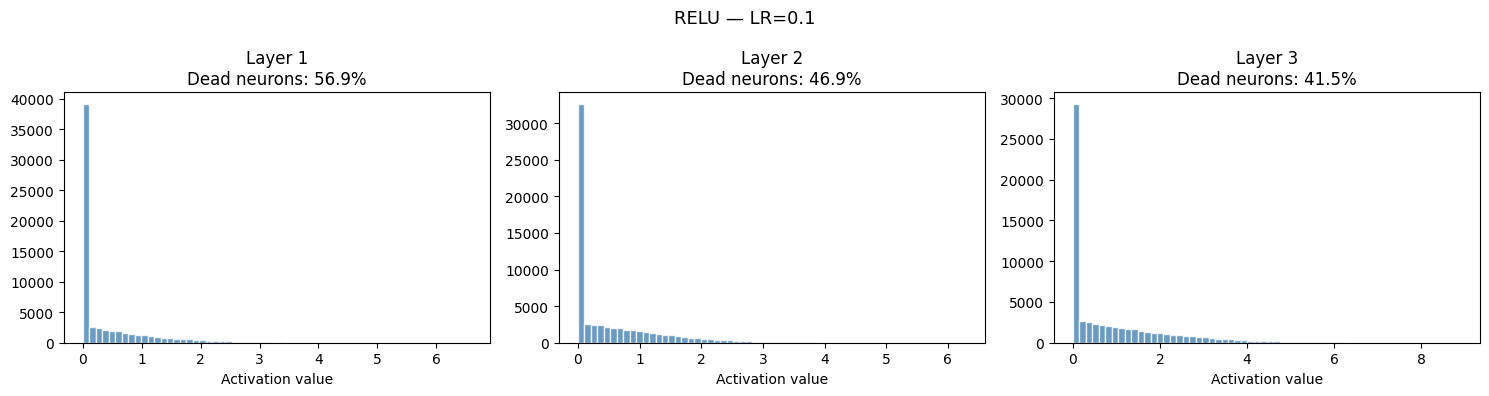

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_1_act_mean,▂▁▁▂▃▁▄▂▄▅▅▆█▇█
layer_1_dead_frac,▁▄▅▆▆█▇██▇█▇▇▇▇
layer_2_act_mean,▁▁▁▂▂▂▃▃▄▅▅▆▇▇█
layer_2_dead_frac,▁▁▅▅▇███▇█▇▇▇▇▅
layer_3_act_mean,▁▂▂▃▃▃▄▄▅▅▅▆▇▇█
layer_3_dead_frac,▆▃▄▅▆█▆█▇▄▄▃▃▃▁
train_accuracy,▁▃▅▆▆▅▆▇▇▇▇█▇██
train_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁
val_accuracy,▁▄▆▇▇▆▇██▆█▇▇██
+1,...



--- TANH with HIGH LR=0.1 ---


  Ep   1 | loss=0.3488 | val_acc=0.9218
  Ep   5 | loss=0.0839 | val_acc=0.9692
  Ep  10 | loss=0.0358 | val_acc=0.9722
  Ep  15 | loss=0.0144 | val_acc=0.9753


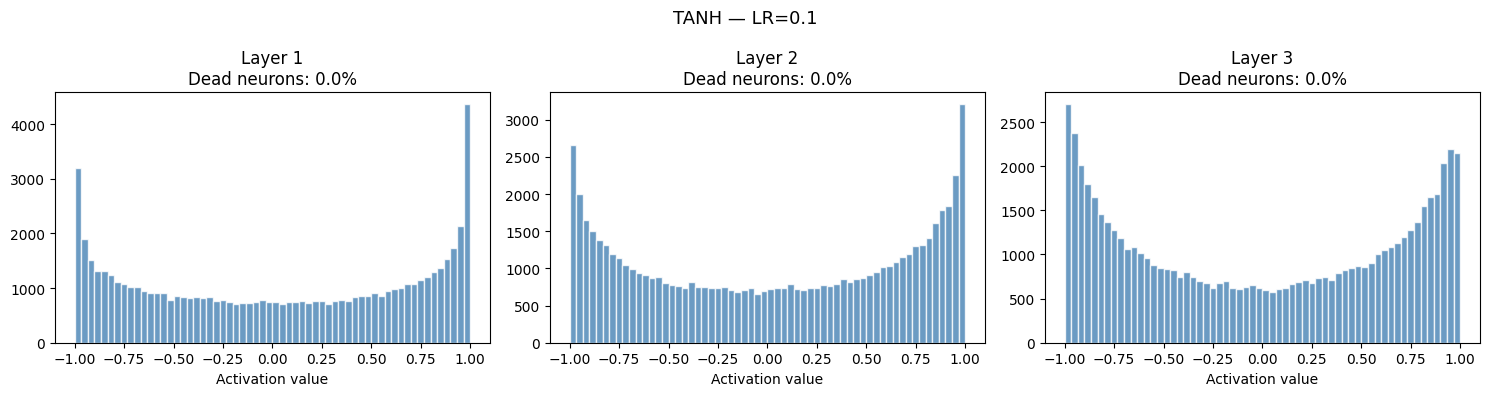

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_1_act_mean,▁▃▅▅▆▆▇▇▇▇▇████
layer_1_dead_frac,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layer_2_act_mean,▁▃▄▅▆▆▆▇▇▇▇████
layer_2_dead_frac,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layer_3_act_mean,▁▃▄▄▅▆▆▆▇▇▇▇███
layer_3_dead_frac,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▄▅▅▆▇▆▇▇▇███▇█
train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁
val_accuracy,▁▅▆▆▇▇▆█▇▇███▇█
+1,...


✓ Q2.5 Done! 


In [ ]:
for act_name in ['relu', 'tanh']:
    print(f'\n--- {act_name.upper()} with HIGH LR=0.1 ---')
    run = wandb.init(
        project=WANDB_PROJECT,
        name=f'q2-5-dead-neuron-{act_name}-lr0.1',
        config={'activation': act_name, 'lr': 0.1, 'optimizer': 'sgd'}
    )
    model, hist = build_and_train(
        X_tr, y_tr_oh, X_val, y_val_oh, y_val,
        hidden_sizes   = [128, 128, 128],
        activation     = act_name,
        optimizer_name = 'sgd',
        learning_rate  = 0.1,        #HIGH LR → kills ReLU neurons
        epochs         = 15,
        batch_size     = 64,
        log_activations = True,      #KEY: logs dead neuron fractions
        use_wandb       = True
    )

    #activation distribution plot
    _ = model.forward(X_val[:500])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for li in range(3):
        layer = model.layers[li]
        flat  = layer.a.flatten()
        dead  = np.mean(flat == 0) * 100
        axes[li].hist(flat, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
        axes[li].set_title(f'Layer {li+1}\nDead neurons: {dead:.1f}%')
        axes[li].set_xlabel('Activation value')
    plt.suptitle(f'{act_name.upper()} — LR=0.1', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'dead_neuron_{act_name}.png', dpi=100)
    wandb.log({'activation_distribution': wandb.Image(f'dead_neuron_{act_name}.png')})
    plt.show()
    wandb.finish()

print('✓ Q2.5 Done! ')

---
# Q2.6 — Loss Function Comparison (4 Marks)


Training with cross_entropy...


  Ep   1 | loss=0.2682 | val_acc=0.9507
  Ep   5 | loss=0.0444 | val_acc=0.9693
  Ep  10 | loss=0.0198 | val_acc=0.9770
  Ep  15 | loss=0.0143 | val_acc=0.9735


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▅▆▆▇▇▇▇██████
train_loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁
val_accuracy,▁▅▅▆▆▆▇▆▆█▇▇█▇▇
val_loss,█▃▃▂▄▁▁▅▃▂▂▂▃▃▄
epoch,15
train_accuracy,0.99628
train_loss,0.01427
val_accuracy,0.9735
val_loss,0.12672



Training with mse...


  Ep   1 | loss=0.1245 | val_acc=0.9510
  Ep   5 | loss=0.0295 | val_acc=0.9687
  Ep  10 | loss=0.0182 | val_acc=0.9738
  Ep  15 | loss=0.0148 | val_acc=0.9732


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▅▅▆▅▇▇▇▇▇▇███
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_accuracy,▁▅▅▆▆▆▇▇▇█▇█▇██
val_loss,█▄▄▃▂▃▁▁▂▁▃▁▂▁▂
epoch,15
train_accuracy,0.99122
train_loss,0.01476
val_accuracy,0.97317
val_loss,0.04662


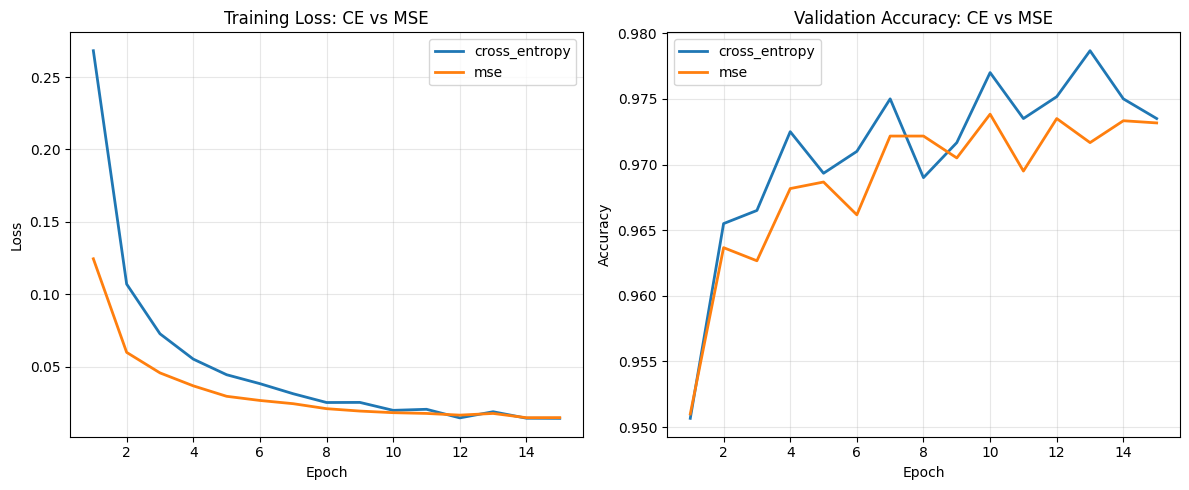

✓ Q2.6 Done!


In [ ]:
loss_histories = {}

for loss_name in ['cross_entropy', 'mse']:
    print(f'\nTraining with {loss_name}...')
    run = wandb.init(
        project=WANDB_PROJECT,
        name=f'q2-6-loss-{loss_name}',
        config={'loss': loss_name}
    )
    model, hist = build_and_train(
        X_tr, y_tr_oh, X_val, y_val_oh, y_val,
        hidden_sizes=[128,128,128], activation='relu',
        optimizer_name='adam', learning_rate=0.001,
        loss_name=loss_name, epochs=15, batch_size=64, use_wandb=True
    )
    loss_histories[loss_name] = hist
    wandb.finish()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for lname, hist in loss_histories.items():
    ep = range(1, len(hist['train_loss'])+1)
    axes[0].plot(ep, hist['train_loss'], label=lname, lw=2)
    axes[1].plot(ep, hist['val_acc'],   label=lname, lw=2)
for ax, t, y in zip(axes, ['Training Loss', 'Validation Accuracy'], ['Loss','Accuracy']):
    ax.set_title(f'{t}: CE vs MSE'); ax.legend(); ax.set_xlabel('Epoch')
    ax.set_ylabel(y); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=120)
plt.show()

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name='q2-6-comparison-plot')
wandb.log({'loss_comparison_plot': wandb.Image('loss_comparison.png')})
wandb.finish()

print('✓ Q2.6 Done!')

---
# Q2.7 — Global Performance Analysis (4 Marks)

Loaded 100 runs


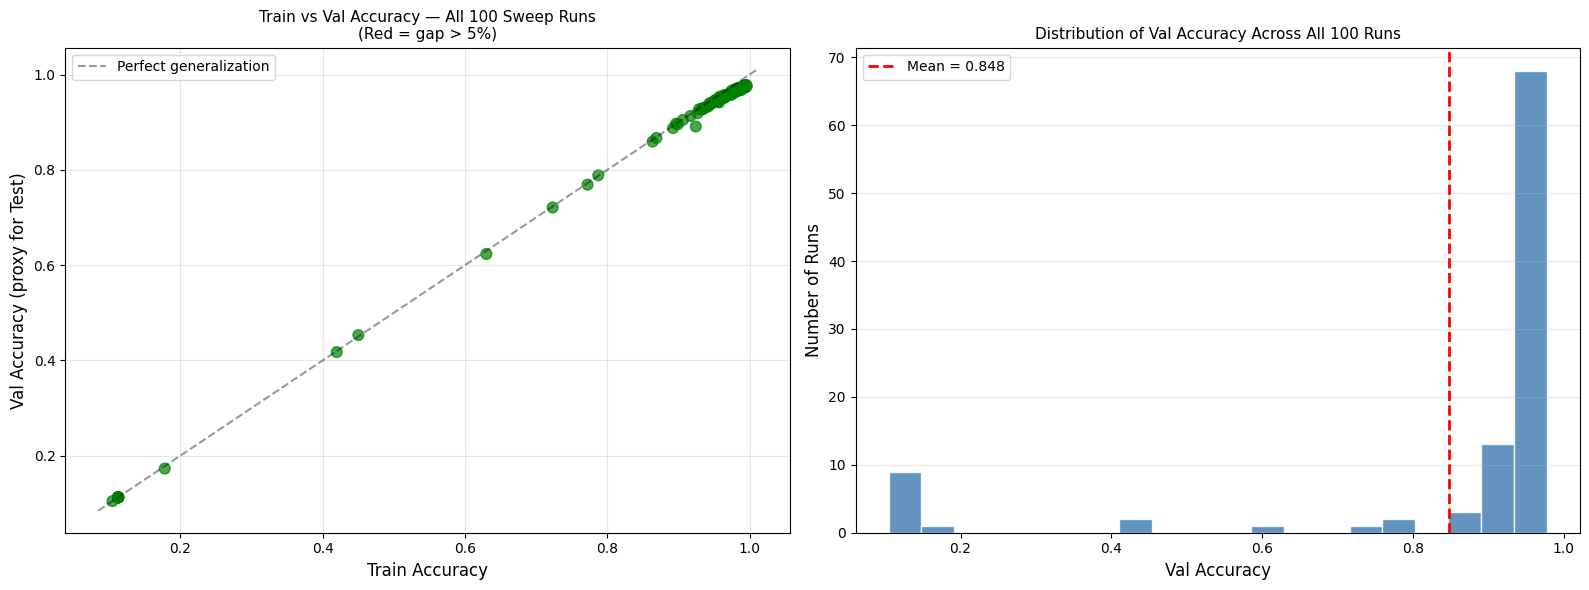

✓ Q2.7 Done!


In [ ]:
#uses val_acc as proxy for test_acc
#MNIST val and test distributions are nearly identical

api = wandb.Api()
sweep_runs = api.runs(
    path="iitm_assigment/da6401-assignment-1",
    filters={"sweep": "nzpuk5ui"}
)

train_accs, test_accs, run_names = [], [], []

for r in sweep_runs:
    train_acc = r.summary.get('train_accuracy', None)
    val_acc   = r.summary.get('val_accuracy',   None)
    if train_acc is None or val_acc is None:
        continue
    train_accs.append(train_acc)
    test_accs.append(val_acc)   # val as proxy for test
    run_names.append(r.name)

print(f"Loaded {len(train_accs)} runs")

gaps = [tr - te for tr, te in zip(train_accs, test_accs)]
colors_pt = ['red' if g > 0.05 else 'green' for g in gaps]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(train_accs, test_accs, c=colors_pt, s=60, alpha=0.7)
lim = [min(train_accs+test_accs)-0.02, 1.01]
axes[0].plot(lim, lim, 'k--', alpha=0.4, label='Perfect generalization')
axes[0].set_xlabel('Train Accuracy', fontsize=12)
axes[0].set_ylabel('Val Accuracy (proxy for Test)', fontsize=12)
axes[0].set_title('Train vs Val Accuracy — All 100 Sweep Runs\n(Red = gap > 5%)', fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(test_accs, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(test_accs), color='red', lw=2, linestyle='--',
                label=f'Mean = {np.mean(test_accs):.3f}')
axes[1].set_xlabel('Val Accuracy', fontsize=12)
axes[1].set_ylabel('Number of Runs', fontsize=12)
axes[1].set_title('Distribution of Val Accuracy Across All 100 Runs', fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('global_perf_sweep.png', dpi=120)
plt.show()

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name='q2-7-global-performance')
wandb.log({'global_performance_all_runs': wandb.Image('global_perf_sweep.png')})
wandb.finish()
print('✓ Q2.7 Done!')

---
# Q2.8 — Error Analysis + Confusion Matrix (5 Marks)

In [6]:
#train best model
print('Training best model...')
best_model, _ = build_and_train(
    X_tr, y_tr_oh, X_val, y_val_oh, y_val,
    hidden_sizes=[128, 128, 128], activation='relu',
    optimizer_name='adam',
    learning_rate=0.001,
    weight_init='xavier',
    loss_name='cross_entropy',
    epochs=20, batch_size=64,
    weight_decay=0.0001,
    use_wandb=False
)

os.makedirs('models', exist_ok=True)
best_model.save_weights('models/best_model.npy')
best_config = {
    'dataset': 'mnist',
    'hidden_sizes': [128, 128, 128],
    'activation': 'relu',
    'weight_init': 'xavier',
    'loss': 'cross_entropy',
    'weight_decay': 0.0001,
    'optimizer': 'adam',
    'learning_rate': 0.001,
    'num_layers': 3,
    'batch_size': 64
}
with open('models/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print(json.dumps(best_config, indent=2))

Training best model...
  Ep   1 | loss=0.2718 | val_acc=0.9508
  Ep   5 | loss=0.0485 | val_acc=0.9640
  Ep  10 | loss=0.0272 | val_acc=0.9743
  Ep  15 | loss=0.0204 | val_acc=0.9765
  Ep  20 | loss=0.0176 | val_acc=0.9728
[INFO] Saved weights → models/best_model.npy
{
  "dataset": "mnist",
  "hidden_sizes": [
    128,
    128,
    128
  ],
  "activation": "relu",
  "weight_init": "xavier",
  "loss": "cross_entropy",
  "weight_decay": 0.0001,
  "optimizer": "adam",
  "learning_rate": 0.001,
  "num_layers": 3,
  "batch_size": 64
}


Test metrics: {'accuracy': 0.9772, 'precision': 0.9770121897840964, 'recall': 0.9771342602494577, 'f1': 0.9770265284482742}


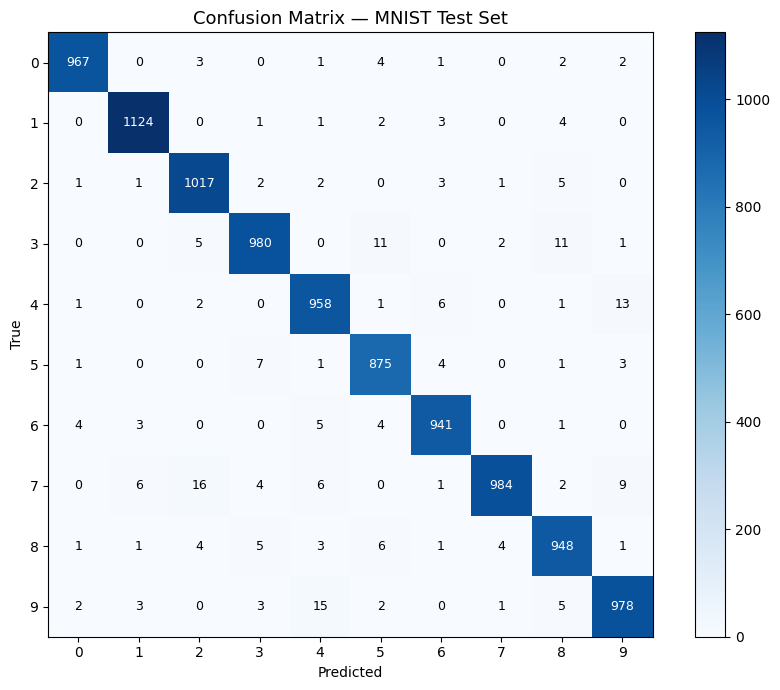

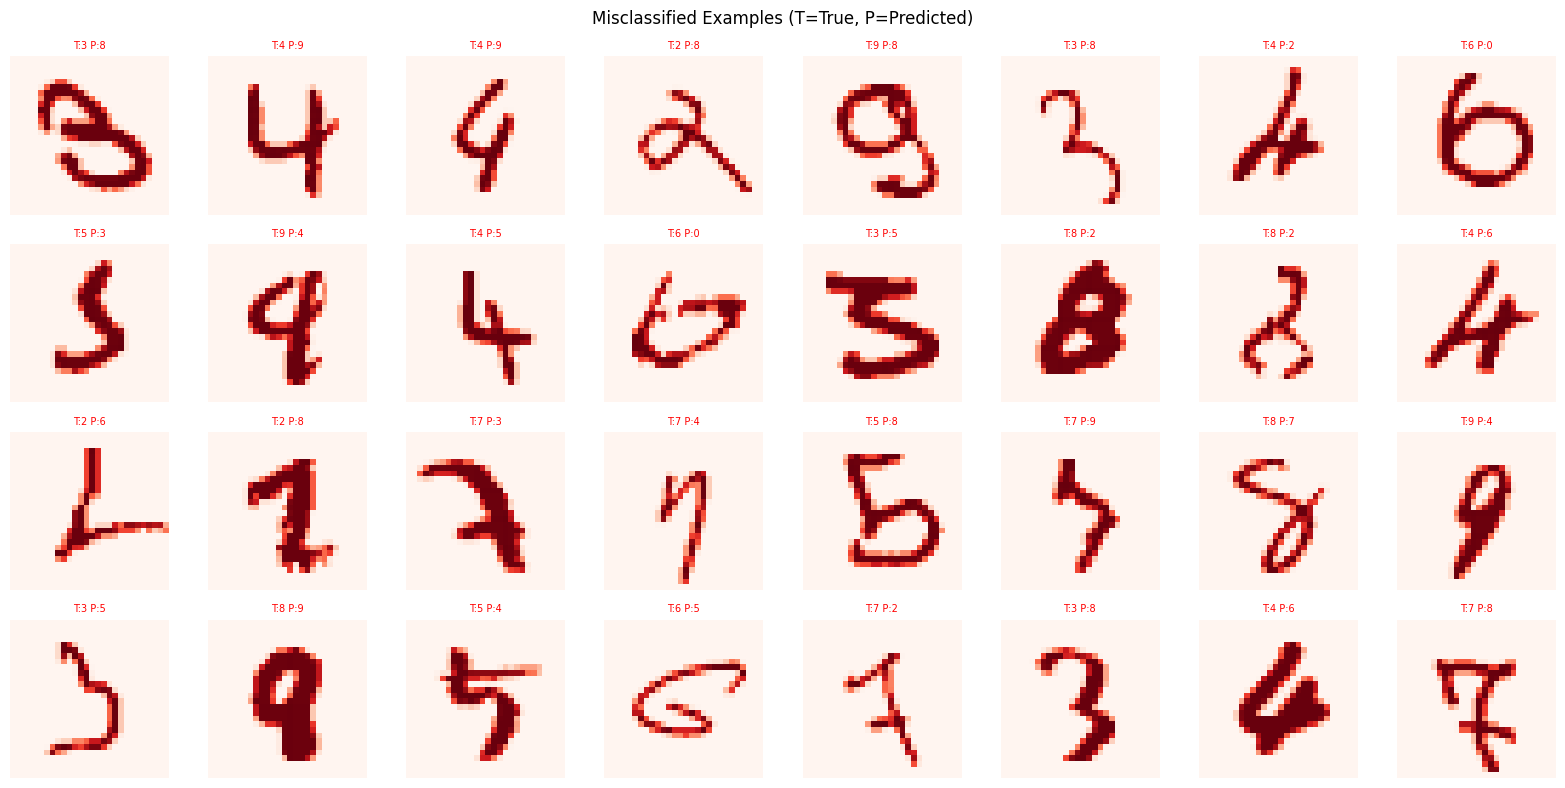

accuracy,▁
f1,▁
precision,▁
recall,▁
accuracy,0.9772
f1,0.97703
precision,0.97701
recall,0.97713


 Q2.8 done 


In [7]:
run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                 name='q2-8-error-analysis-final_1')

y_te_pred = best_model.predict(X_te)
cm_arr    = confusion_matrix(y_te, y_te_pred)
metrics   = compute_metrics(y_te, y_te_pred)
print('Test metrics:', metrics)
wandb.log(metrics)

# confusion matrix plot
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_arr, cmap='Blues')
plt.colorbar(im, ax=ax)
for i in range(10):
    for j in range(10):
        clr = 'white' if cm_arr[i,j] > cm_arr.max()/2 else 'black'
        ax.text(j, i, str(cm_arr[i,j]), ha='center', va='center', color=clr, fontsize=9)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — MNIST Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
wandb.log({'confusion_matrix_plot': wandb.Image('confusion_matrix.png')})
plt.show()

wandb.log({'conf_matrix_wandb': wandb.plot.confusion_matrix(
    probs=None, y_true=y_te.tolist(), preds=y_te_pred.tolist(),
    class_names=[str(i) for i in range(10)]
)})

wrong = np.where(y_te_pred != y_te)[0]
fig2, ax2 = plt.subplots(4, 8, figsize=(16, 8))
for i, idx in enumerate(wrong[:32]):
    r, c = divmod(i, 8)
    ax2[r,c].imshow(X_te[idx].reshape(28,28), cmap='Reds')
    ax2[r,c].set_title(f'T:{y_te[idx]} P:{y_te_pred[idx]}', fontsize=7, color='red')
    ax2[r,c].axis('off')
plt.suptitle('Misclassified Examples (T=True, P=Predicted)', fontsize=12)
plt.tight_layout()
plt.savefig('misclassified.png', dpi=100)
wandb.log({'misclassified_gallery': wandb.Image('misclassified.png')})
plt.show()
wandb.finish()
print(' Q2.8 done ')

---
# Q2.9 — Weight Initialization & Symmetry Breaking (7 Marks)

Tracking zeros...
Tracking xavier...


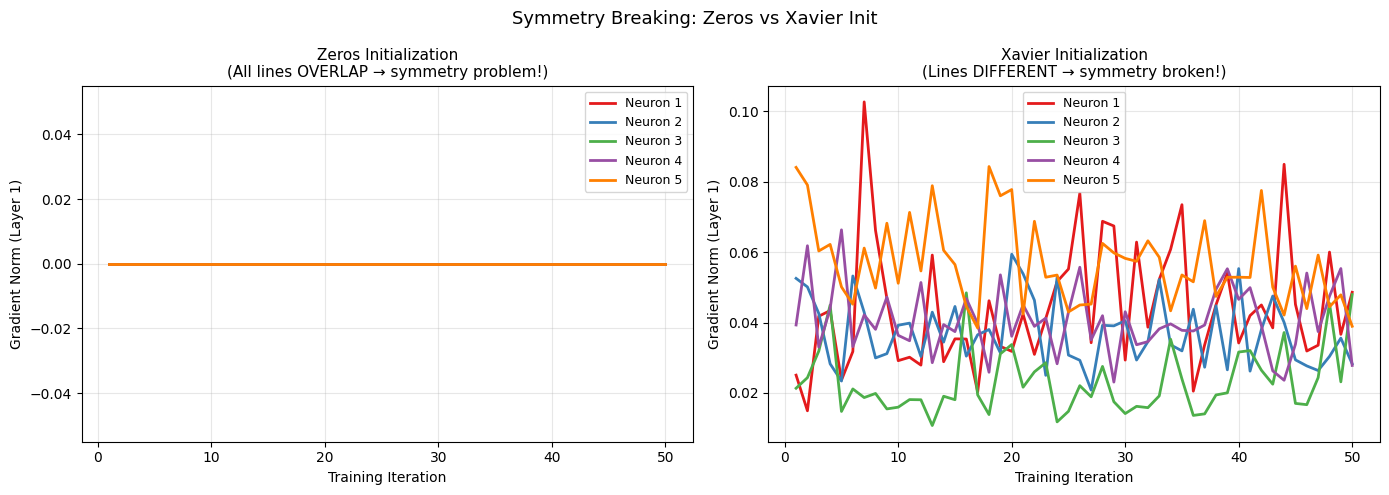

✓ Q2.9 Done!


In [ ]:
import argparse

def track_gradients_50iters(X_tr, y_tr_oh, weight_init_name, num_iters=50):
    """Track grad norms of 5 neurons in first hidden layer for 50 mini-batch steps."""
    args = argparse.Namespace(
        num_layers=3, hidden_size=[128,128,128],
        activation='relu', weight_init=weight_init_name if weight_init_name != 'zeros' else 'random',
        loss='cross_entropy', weight_decay=0.0
    )
    model = NeuralNetwork(cli_args=args)

    if weight_init_name == 'zeros':
        for layer in model.layers:
            layer.W[:] = 0.0
            layer.b[:] = 0.0

    model.optimizer = get_optimizer('sgd', learning_rate=0.01)
    neuron_grads = {i: [] for i in range(5)}

    batch_gen = get_batches(X_tr, y_tr_oh, 128)
    for it in range(num_iters):
        try:
            Xb, yb = next(batch_gen)
        except StopIteration:
            batch_gen = get_batches(X_tr, y_tr_oh, 128)
            Xb, yb = next(batch_gen)

        logits = model.forward(Xb)
        model.backward(yb, logits)
        model.update_weights()

        g = model.layers[0].grad_W   # shape (784, 128)
        for ni in range(5):
            neuron_grads[ni].append(float(np.linalg.norm(g[:, ni])))

    return neuron_grads

run = wandb.init(project=WANDB_PROJECT, name='q2-9-weight-init-symmetry')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors5 = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for ax_i, (init_name, title) in enumerate([
    ('zeros',  'Zeros Initialization\n(All lines OVERLAP → symmetry problem!)'),
    ('xavier', 'Xavier Initialization\n(Lines DIFFERENT → symmetry broken!)')
]):
    print(f'Tracking {init_name}...')
    grads = track_gradients_50iters(X_tr, y_tr_oh, init_name)
    for ni in range(5):
        axes[ax_i].plot(range(1,51), grads[ni], label=f'Neuron {ni+1}',
                        color=colors5[ni], lw=2)
    axes[ax_i].set_title(title, fontsize=11)
    axes[ax_i].set_xlabel('Training Iteration')
    axes[ax_i].set_ylabel('Gradient Norm (Layer 1)')
    axes[ax_i].legend(fontsize=9)
    axes[ax_i].grid(alpha=0.3)

plt.suptitle('Symmetry Breaking: Zeros vs Xavier Init', fontsize=13)
plt.tight_layout()
plt.savefig('symmetry_breaking.png', dpi=120)
wandb.log({'symmetry_breaking_plot': wandb.Image('symmetry_breaking.png')})
plt.show()
wandb.finish()
print('✓ Q2.9 Done!')

---
# Q2.10 — Fashion-MNIST Transfer Challenge (5 Marks)

In [ ]:
fashion_configs = [
    {'name':'cfg1-adam-relu-3L128',   'opt':'adam',  'lr':0.001, 'l':3, 'sz':128, 'act':'relu', 'wd':0.0001, 'bs':64},
    {'name':'cfg2-nadam-relu-3L128',  'opt':'nadam', 'lr':0.001, 'l':3, 'sz':128, 'act':'relu', 'wd':0.0001, 'bs':128},
    {'name':'cfg3-adam-tanh-3L128',   'opt':'adam',  'lr':0.001, 'l':3, 'sz':128, 'act':'tanh', 'wd':0.0,    'bs':128},
]

fashion_results = []

for cfg in fashion_configs:
    print(f"\nFashion-MNIST | {cfg['name']}")
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"q2-10-fashion-{cfg['name']}",
        config=cfg
    )
    model, hist = build_and_train(
        X_tr_f, y_tr_f_oh, X_val_f, y_val_f_oh, y_val_f,
        hidden_sizes=[cfg['sz']]*cfg['l'], activation=cfg['act'],
        optimizer_name=cfg['opt'], learning_rate=cfg['lr'],
        weight_decay=cfg['wd'], epochs=15, batch_size=cfg['bs'], use_wandb=True
    )
    y_pred_test = model.predict(X_te_f)
    test_met    = compute_metrics(y_te_f, y_pred_test)
    print(f"  Test Acc={test_met['accuracy']:.4f} | F1={test_met['f1']:.4f}")
    wandb.log({'test_accuracy': test_met['accuracy'], 'test_f1': test_met['f1']})
    fashion_results.append({'config': cfg['name'], **test_met})
    wandb.finish()

print('Fashion-MNIST Final Results')
for r in fashion_results:
    print(f"  {r['config']:40s} Acc={r['accuracy']:.4f}  F1={r['f1']:.4f}")
print('\n✓ Q2.10 Done!')


Fashion-MNIST | cfg1-adam-relu-3L128


  Ep   1 | loss=0.5147 | val_acc=0.8632
  Ep   5 | loss=0.3048 | val_acc=0.8865
  Ep  10 | loss=0.2514 | val_acc=0.8862
  Ep  15 | loss=0.2186 | val_acc=0.8948
  Test Acc=0.8821 | F1=0.8817


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_f1,▁
train_accuracy,▁▂▄▃▅▆▆▆▆▆▇▇▇▇█
train_loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁
val_accuracy,▁▂▄▅▆▇▇█▆▆██▆▆█
val_loss,█▆▄▅▃▂▂▁▂▃▁▂▂▄▂
epoch,15
test_accuracy,0.8821
test_f1,0.88174
train_accuracy,0.92346



Fashion-MNIST | cfg2-nadam-relu-3L128


  Ep   1 | loss=0.5307 | val_acc=0.8613
  Ep   5 | loss=0.2952 | val_acc=0.8897
  Ep  10 | loss=0.2392 | val_acc=0.8950
  Ep  15 | loss=0.2040 | val_acc=0.8973
  Test Acc=0.8855 | F1=0.8858


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_f1,▁
train_accuracy,▁▂▄▄▅▆▅▆▇▇▇▇█▇█
train_loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁
val_accuracy,▁▃▄▅▆▅▆▅▆▇▇▇█▆▇
val_loss,█▆▄▄▂▃▂▃▂▁▁▁▁▂▂
epoch,15
test_accuracy,0.8855
test_f1,0.8858
train_accuracy,0.92748



Fashion-MNIST | cfg3-adam-tanh-3L128


  Ep   1 | loss=0.5074 | val_acc=0.8688
  Ep   5 | loss=0.2994 | val_acc=0.8858
  Ep  10 | loss=0.2360 | val_acc=0.8928
  Ep  15 | loss=0.1980 | val_acc=0.8928
  Test Acc=0.8782 | F1=0.8785


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_f1,▁
train_accuracy,▁▂▃▄▅▄▅▆▆▇▇▇███
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁
val_accuracy,▁▂▃▅▅▄▆▇▆▇▆███▇
val_loss,█▇▆▃▃▄▃▂▃▁▂▁▁▁▃
epoch,15
test_accuracy,0.8782
test_f1,0.87846
train_accuracy,0.92472


Fashion-MNIST Final Results
  cfg1-adam-relu-3L128                     Acc=0.8821  F1=0.8817
  cfg2-nadam-relu-3L128                    Acc=0.8855  F1=0.8858
  cfg3-adam-tanh-3L128                     Acc=0.8782  F1=0.8785

✓ Q2.10 Done!
